# Locally low rank across contrasts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchdenoise/blob/main/examples/02-llr.ipynb)

The opposite case: it is the correlation *between* contrasts that this
denoiser uses. Within a small spatial block the signal across contrasts is
nearly the same curve scaled, so the block's matrix is close to low rank
while noise is not, and shrinking its singular values removes what does not
fit that description.

[3D denoising demo](https://deepinv.org/auto_examples/optimization/demo_3D_denoising.html),
on a BrainWeb T1 volume, and adds the parts an MRI volume needs: complex data,
a stack of slices or contrasts, and a denoiser that treats the contrast axis as
signal.

In [1]:
try:
    import torchdenoise  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "torchdenoise",
            "brainweb-dl",
            "matplotlib",
        ],
        check=True,
    )

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import torchdenoise as td

torch.manual_seed(0)


def brain(size=128, slices=16):
    """A BrainWeb T1 volume, or ellipses if brainweb-dl is not installed."""
    try:
        from brainweb_dl import get_mri
    except ImportError:
        rows, columns = np.mgrid[-1 : 1 : size * 1j, -1 : 1 : size * 1j]
        disc = ((rows / 0.8) ** 2 + (columns / 0.7) ** 2 < 1).astype(float)
        disc = disc * (1 + 0.3 * np.sin(6 * rows) * np.cos(5 * columns))
        return torch.tensor(np.repeat(disc[None], slices, 0), dtype=torch.float32)
    volume = np.asarray(get_mri(sub_id=4, contrast="T1"), dtype=float)
    middle = volume.shape[0] // 2
    taken = volume[middle - slices // 2 : middle + slices // 2]
    index = np.linspace(0, taken.shape[-1] - 1, size).round().astype(int)
    taken = np.rot90(taken[:, index][:, :, index], 2, axes=(1, 2))
    return torch.tensor(taken.copy() / taken.max(), dtype=torch.float32)


truth = brain()
noise = 0.08
noisy = truth + noise * torch.randn_like(truth)
print("volume", tuple(truth.shape))

# ## Locally low rank
#
# The denoisers above treat the contrast axis as something to work around. This
# one uses it: within a small block the signal across contrasts is nearly the same
# curve scaled, so the block's matrix — a row per contrast, a column per voxel —
# is close to low rank, while noise is not. Shrinking its singular values removes
# what does not fit that description. It needs contrasts to work with: on four it
# has little to exploit and a wavelet does as well, and the sixteen here are what
# a relaxation series actually gives.
#
# Blocks are non-overlapping and the grid is shifted at random between calls,
# which is what stops the block edges showing as a lattice over the several passes
# of an iterative reconstruction.

/home/mcencini/torchdenoise/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


volume (16, 128, 128)


In [3]:
# Sixteen contrasts of a relaxation series: two tissue pools, each decaying at
# its own rate, so the series is rank two however many contrasts are measured.
time = torch.linspace(0, 1, 16)[:, None]
curves = torch.cat([torch.exp(-time * 1.0), torch.exp(-time * 4.0)], dim=1)
fast = (truth > 0.55).float() * truth
maps = torch.stack([truth - fast, fast])

# The contrast axis goes immediately before the spatial ones, so where it sits
# depends on how many axes are spatial. For the 2D denoiser below, z is not
# spatial and the layout is (z, contrasts, y, x); for a 3D one it would be
# (contrasts, z, y, x) with nothing independent in front. Getting this the wrong
# way round denoises the wrong axis and raises nothing.
series = torch.einsum("cr,rsyx->scyx", curves, maps)  # (z, contrasts, y, x)
noisy_series = series + noise * torch.randn_like(series)

low_rank = td.LLR(spatial_dims=2, block_size=8)(noisy_series, 0.4)
spatial_only = td.Wavelet(spatial_dims=2)(noisy_series, noise)

err = lambda x: float((x - series).norm() / series.norm())
print(f"noisy            {err(noisy_series):.4f}")
print(f"wavelet, 2D      {err(spatial_only):.4f}")
print(f"locally low rank {err(low_rank):.4f}")

# The same series for the 3D denoiser: contrasts first, all three spatial axes
# behind them, and no independent axis left over.
volumetric_series = noisy_series.movedim(1, 0)  # (contrasts, z, y, x)
print(
    "3D layout:",
    tuple(volumetric_series.shape),
    "->",
    tuple(td.LLR(spatial_dims=3, block_size=8)(volumetric_series, 0.4).shape),
)

noisy            0.4899
wavelet, 2D      0.2774
locally low rank 0.2441
3D layout: (16, 16, 128, 128) -> (16, 16, 128, 128)


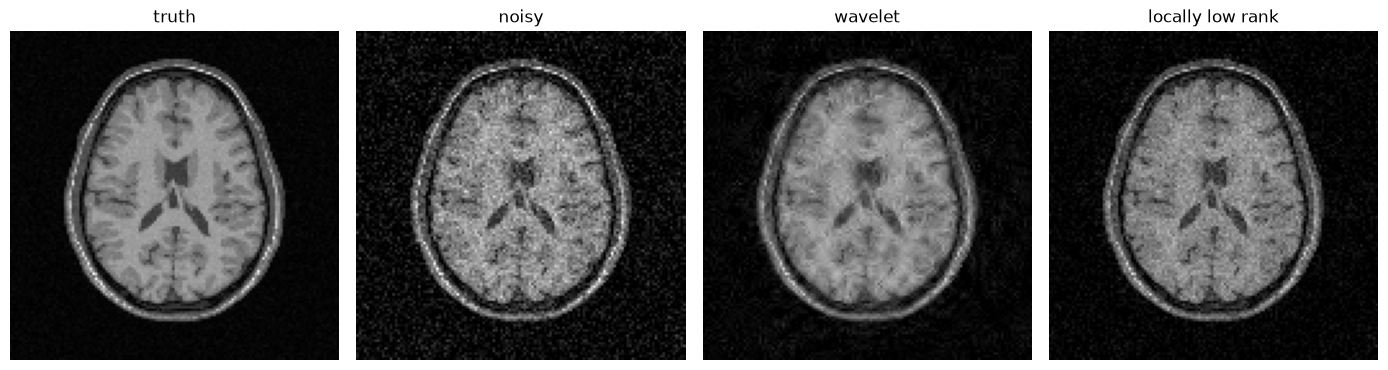

In [4]:
figure, axes = plt.subplots(1, 4, figsize=(14, 3.6))
top = float(series[8, 0].max())
for axis, (image, title) in zip(
    axes,
    (
        (series[8, 0], "truth"),
        (noisy_series[8, 0], "noisy"),
        (spatial_only[8, 0], "wavelet"),
        (low_rank[8, 0], "locally low rank"),
    ),
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=top)
    axis.set_title(title)
    axis.axis("off")
figure.tight_layout()